# Understanding the Opioid Crisis: An Analysis of Overdose Trends Across States, Demographics, and Drug Types

Author: Alissa N. Beaderstadt<br>
Northwest Missouri State University, Maryville MO 64468, USA<br>
Email: S528352@nwmissouri.edu and alissabeaderstadt@outlook.com<br>

## Dataset info

## Section 1. Imports

In [44]:
from matplotlib.axes import Axes
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Display settings
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print("Imports complete.")

Imports complete.


## Section 2. Load Data
Before analysis, load the data to confirm:

- The dataset loads successfully
- The structure matches expectations
- Column names are available and readable

In [45]:
# Primary state-by-year dataset
master_df = pd.read_csv("../data/processed/merged_opioid_deaths.csv")

# Supporting demographic datasets
age_df = pd.read_csv("../data/processed/age_processed.csv")
sex_df = pd.read_csv("../data/processed/sex_processed.csv")
race_df = pd.read_csv("../data/processed/race_processed.csv")

# Preview the shape and info of the master dataset
master_df.shape
master_df.info()

# Preview the first few rows
master_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1122 entries, 0 to 1121
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   state                    1122 non-null   str    
 1   state_code               1122 non-null   float64
 2   year                     1122 non-null   int64  
 3   year_code                1122 non-null   float64
 4   opioid_deaths            1085 non-null   float64
 5   population               1122 non-null   float64
 6   opioid_death_rate        1040 non-null   float64
 7   heroin_deaths            811 non-null    float64
 8   heroin_death_rate        661 non-null    float64
 9   other_deaths             740 non-null    float64
 10  other_death_rate         518 non-null    float64
 11  methadone_deaths         913 non-null    float64
 12  methadone_death_rate     732 non-null    float64
 13  synthetic_deaths         858 non-null    float64
 14  synthetic_death_rate     643 non-nu

,state,state_code,year,year_code,opioid_deaths,population,opioid_death_rate,heroin_deaths,heroin_death_rate,other_deaths,other_death_rate,methadone_deaths,methadone_death_rate,synthetic_deaths,synthetic_death_rate,prescription_deaths,prescription_death_rate
0,Alabama,1.00,1999,"1,999.00",26.00,"4,430,141.00",0.60,NaN,NaN,NaN,NaN,14.00,NaN,NaN,NaN,NaN,NaN
1,Alabama,1.00,2000,"2,000.00",31.00,"4,447,100.00",0.70,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.00,NaN
2,Alabama,1.00,2001,"2,001.00",47.00,"4,467,634.00",1.10,NaN,NaN,NaN,NaN,22.00,0.50,NaN,NaN,19.00,NaN
3,Alabama,1.00,2002,"2,002.00",61.00,"4,480,089.00",1.40,NaN,NaN,NaN,NaN,30.00,0.70,NaN,NaN,26.00,0.60
4,Alabama,1.00,2003,"2,003.00",40.00,"4,503,491.00",0.90,NaN,NaN,NaN,NaN,23.00,0.50,NaN,NaN,18.00,NaN


In [46]:
analysis_df = master_df.drop(columns=["state_code", "year_code"])

# Preview the shape and info of the cleaned master dataset
analysis_df.shape
analysis_df.info()

# Preview the first few rows
analysis_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1122 entries, 0 to 1121
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   state                    1122 non-null   str    
 1   year                     1122 non-null   int64  
 2   opioid_deaths            1085 non-null   float64
 3   population               1122 non-null   float64
 4   opioid_death_rate        1040 non-null   float64
 5   heroin_deaths            811 non-null    float64
 6   heroin_death_rate        661 non-null    float64
 7   other_deaths             740 non-null    float64
 8   other_death_rate         518 non-null    float64
 9   methadone_deaths         913 non-null    float64
 10  methadone_death_rate     732 non-null    float64
 11  synthetic_deaths         858 non-null    float64
 12  synthetic_death_rate     643 non-null    float64
 13  prescription_deaths      1013 non-null   float64
 14  prescription_death_rate  891 non-nu

,state,year,opioid_deaths,population,opioid_death_rate,heroin_deaths,heroin_death_rate,other_deaths,other_death_rate,methadone_deaths,methadone_death_rate,synthetic_deaths,synthetic_death_rate,prescription_deaths,prescription_death_rate
0,Alabama,1999,26.00,"4,430,141.00",0.60,NaN,NaN,NaN,NaN,14.00,NaN,NaN,NaN,NaN,NaN
1,Alabama,2000,31.00,"4,447,100.00",0.70,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.00,NaN
2,Alabama,2001,47.00,"4,467,634.00",1.10,NaN,NaN,NaN,NaN,22.00,0.50,NaN,NaN,19.00,NaN
3,Alabama,2002,61.00,"4,480,089.00",1.40,NaN,NaN,NaN,NaN,30.00,0.70,NaN,NaN,26.00,0.60
4,Alabama,2003,40.00,"4,503,491.00",0.90,NaN,NaN,NaN,NaN,23.00,0.50,NaN,NaN,18.00,NaN


## Section 3. Data Quality Assessment

In [47]:
# Check for missing values in the cleaned master dataset
analysis_df.isna().sum().sort_values(ascending=False)

other_death_rate           604
synthetic_death_rate       479
heroin_death_rate          461
methadone_death_rate       390
other_deaths               382
heroin_deaths              311
synthetic_deaths           264
prescription_death_rate    231
methadone_deaths           209
prescription_deaths        109
opioid_death_rate           82
opioid_deaths               37
population                   0
state                        0
year                         0
dtype: int64

In [48]:
# Check for duplicate rows in the cleaned master dataset
analysis_df.duplicated(
    subset=["state", "year"]
).sum()
print(f"Duplicate rows in cleaned master dataset: {analysis_df.duplicated(subset=['state', 'year']).sum()}")

Duplicate rows in cleaned master dataset: 0


In [49]:
# Unique values
analysis_df["state"].nunique()
print(f"Unique states in cleaned master dataset: {analysis_df['state'].nunique()}")

analysis_df["year"].min()
print(f"Minimum year in cleaned master dataset: {analysis_df['year'].min()}")

analysis_df["year"].max()
print(f"Maximum year in cleaned master dataset: {analysis_df['year'].max()}")

Unique states in cleaned master dataset: 51
Minimum year in cleaned master dataset: 1999
Maximum year in cleaned master dataset: 2020


In [50]:
missing_opioid = analysis_df["opioid_deaths"].isna().sum()
print(f"Missing opioid death values: {missing_opioid}")

Missing opioid death values: 37


The primary opioid deaths variable contains 37 missing observations (3.3% of the dataset). Examination of the original CDC WONDER files showed that these correspond to suppressed counts, primarily among smaller-population states during earlier years of the study period. These values were intentionally retained as NaN because they represent unavailable data rather than zero deaths.

## Section 4. Descriptive Statistics

In [51]:
describe_df = analysis_df.describe().round(2)
print(describe_df)

          year  opioid_deaths    population  opioid_death_rate  heroin_deaths  heroin_death_rate  other_deaths  \
count 1,122.00       1,085.00      1,122.00           1,040.00         811.00             661.00        740.00   
mean  2,009.50         450.09  6,012,795.59               7.98         165.11               2.96         59.31   
std       6.35         630.81  6,756,332.37               7.23         230.92               2.73         80.66   
min   1,999.00           0.00    491,780.00               0.40           0.00               0.10          0.00   
25%   2,004.00          74.00  1,661,982.50               3.50          28.00               1.00         17.00   
50%   2,009.50         240.00  4,214,329.00               5.70          77.00               2.10         32.00   
75%   2,015.00         539.00  6,891,085.75               9.60         202.50               4.10         62.00   
max   2,020.00       5,313.00 39,557,045.00              62.00       1,445.00           

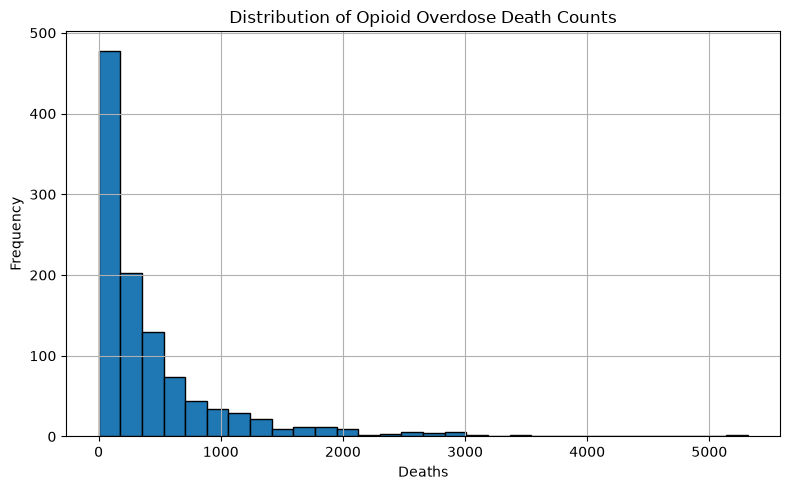

In [52]:
# Counts of deaths
plt.figure(figsize=(8,5))

analysis_df["opioid_deaths"].hist(
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Opioid Overdose Death Counts")
plt.xlabel("Deaths")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

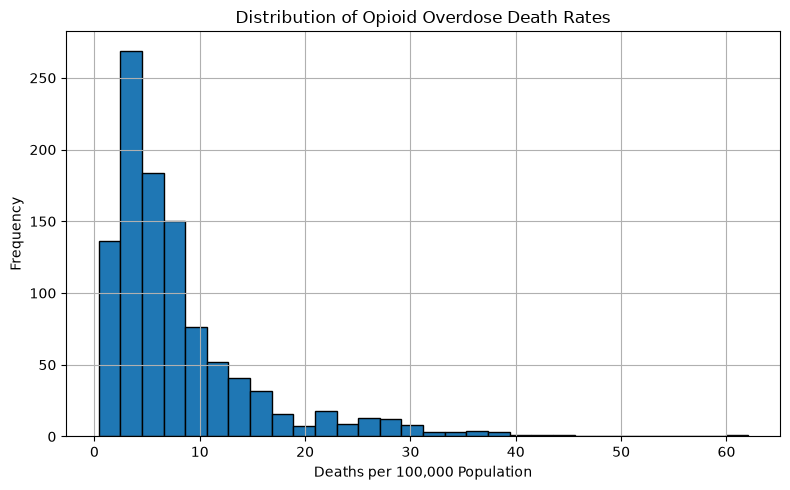

In [53]:
# rates
plt.figure(figsize=(8,5))

analysis_df["opioid_death_rate"].hist(
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Opioid Overdose Death Rates")
plt.xlabel("Deaths per 100,000 Population")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

The distribution of opioid overdose deaths is strongly right-skewed. Most state-year observations have relatively low numbers of overdose deaths, while a small number of highly populated states contribute exceptionally large counts. This suggests that analyses based on death rates may provide more meaningful comparisons across states than raw counts alone.